In [34]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torchsummary import summary
from torch.utils.data import TensorDataset, Dataset, DataLoader
!pip install torchview
from torchview import draw_graph
!pip install rangerlite
from rangerlite import RangerLite
!pip install pytorch-optimizer
from pytorch_optimizer import Ranger


if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import cv2
import copy
import shutil
from itertools import product
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from PIL import Image, ImageOps
import matplotlib.gridspec as gridspec
import requests
import re
from io import BytesIO
import torch.optim as optim
from collections import defaultdict
import gc
from torchvision.models import ResNet18_Weights

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

PyTorch version: 2.6.0+cu124
Device: cuda


In [35]:
def sample_centers_from_mask(mask, n, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return []
    idx = rng.integers(0, len(xs), size=n)
    return list(zip(xs[idx], ys[idx]))

def crop_patch(arr, cx, cy, patch):
    H, W = arr.shape[:2]
    x0 = int(np.clip(cx - patch//2, 0, W - patch))
    y0 = int(np.clip(cy - patch//2, 0, H - patch))
    return arr[y0:y0+patch, x0:x0+patch]

def extract_patches_maskaware(img, mask, patch=256, n_patches=6,
                             fallback="random", min_mask_frac=0.01,
                             max_tries=50, rng=None):
    """
    Estrae patch guidate dalla maschera (mask>0).
    - fallback: "random" oppure "tissue" (se implementi tissue mask) oppure "center"
    - min_mask_frac: patch accettata solo se contiene un minimo di mask
    """
    if rng is None:
        rng = np.random.default_rng()

    H, W = mask.shape

    if H == patch and W == patch:
        return [(img, mask)]
    
    patches = []
    tries = 0

    while len(patches) < n_patches and tries < max_tries:
        tries += 1

        centers = sample_centers_from_mask(mask, 1, rng=rng)

        if centers:
            cx, cy = centers[0]
        else:
            # fallback se mask vuota
            if fallback == "center":
                cx, cy = W//2, H//2
            else:
                cx = int(rng.integers(0, W))
                cy = int(rng.integers(0, H))

        ip = crop_patch(img,  cx, cy, patch)
        mp = crop_patch(mask, cx, cy, patch)

        # accetta solo se la patch contiene un minimo di mask (quando la mask non è vuota)
        if mask.sum() > 0 and mp.mean() < min_mask_frac:
            continue

        patches.append((ip, mp))

    # se non trovi patch valide, fai fallback
    if not patches:
        cx = int(rng.integers(0, W))
        cy = int(rng.integers(0, H))
        patches.append((crop_patch(img, cx, cy, patch), crop_patch(mask, cx, cy, patch)))

    return patches

In [43]:
def get_bbox(mask):
    ys, xs = np.where(mask > 0)
    if xs.size == 0:
        return None
    return xs.min(), ys.min(), xs.max() + 1, ys.max() + 1

def extract_crop_from_mask(arr, mask, min_size=256):
    bbox = get_bbox(mask)
    if bbox is None:
        return arr  # niente crop
    x0, y0, x1, y1 = bbox
    # se bbox troppo piccola -> niente crop
    if (x1 - x0) < min_size or (y1 - y0) < min_size:
        return arr
    return arr[y0:y1, x0:x1]

def pad_to_min_size(arr, min_size=256):
    H, W = arr.shape[:2]
    if H >= min_size and W >= min_size:
        return arr

    dh = max(0, min_size - H)
    dw = max(0, min_size - W)

    top = dh // 2
    bottom = dh - top
    left = dw // 2
    right = dw - left

    return cv2.copyMakeBorder(
        arr, top, bottom, left, right,
        borderType=cv2.BORDER_CONSTANT,
        value=0
    )

def load_images_from_folder(folder):
    imgs, masks, file_names = [], [], []
    filenames = sorted([f for f in os.listdir(folder)
                        if f.startswith("img") and f.endswith(".png")])

    for filename in filenames:
        img = cv2.imread(os.path.join(folder, filename))
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # mucus filter
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        lower = np.array([35, 80, 160], dtype=np.uint8)
        upper = np.array([60, 255, 255], dtype=np.uint8)
        M_art = cv2.inRange(hsv, lower, upper)
        if np.mean(M_art > 0) >= 0.01:
            continue

        mask_name = filename.replace("img", "mask")
        mask = cv2.imread(os.path.join(folder, mask_name), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            continue
        mask = (mask > 0).astype(np.uint8)

        # crop su bbox mask (ma solo se bbox non è ridicola)
        img_crop  = extract_crop_from_mask(img,  mask, min_size=256)
        mask_crop = extract_crop_from_mask(mask, mask, min_size=256)

        # padding se il crop è più piccolo di 256 in una delle due dimensioni
        img_crop  = pad_to_min_size(img_crop,  min_size=256)
        mask_crop = pad_to_min_size(mask_crop, min_size=256)

        # garantisci binaria (padding ha messo zeri, quindi è già ok; ma safe)
        mask_crop = (mask_crop > 0).astype(np.uint8)

        # applica mask
        #img_masked = img_crop * mask_crop[..., None]  # (H,W,3) * (H,W,1)

        imgs.append(img_crop)
        masks.append(mask_crop)
        file_names.append(filename)

    return imgs, masks, file_names

In [44]:
data, masks, file_names = load_images_from_folder("/kaggle/input/tissues-noshrek/an2dl2526c2v2/train_data")
print(f"Loaded {len(data)} data")

Loaded 581 data


In [45]:
def plot_10_images(data, titles=None):
    assert len(data) >= 10, "Servono almeno 10 immagini"

    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    axes = axes.flatten()

    for i in range(10):
        axes[i].imshow(data[i])
        axes[i].axis("off")
        if titles is not None:
            axes[i].set_title(titles[i], fontsize=10)

    plt.tight_layout()
    plt.show()

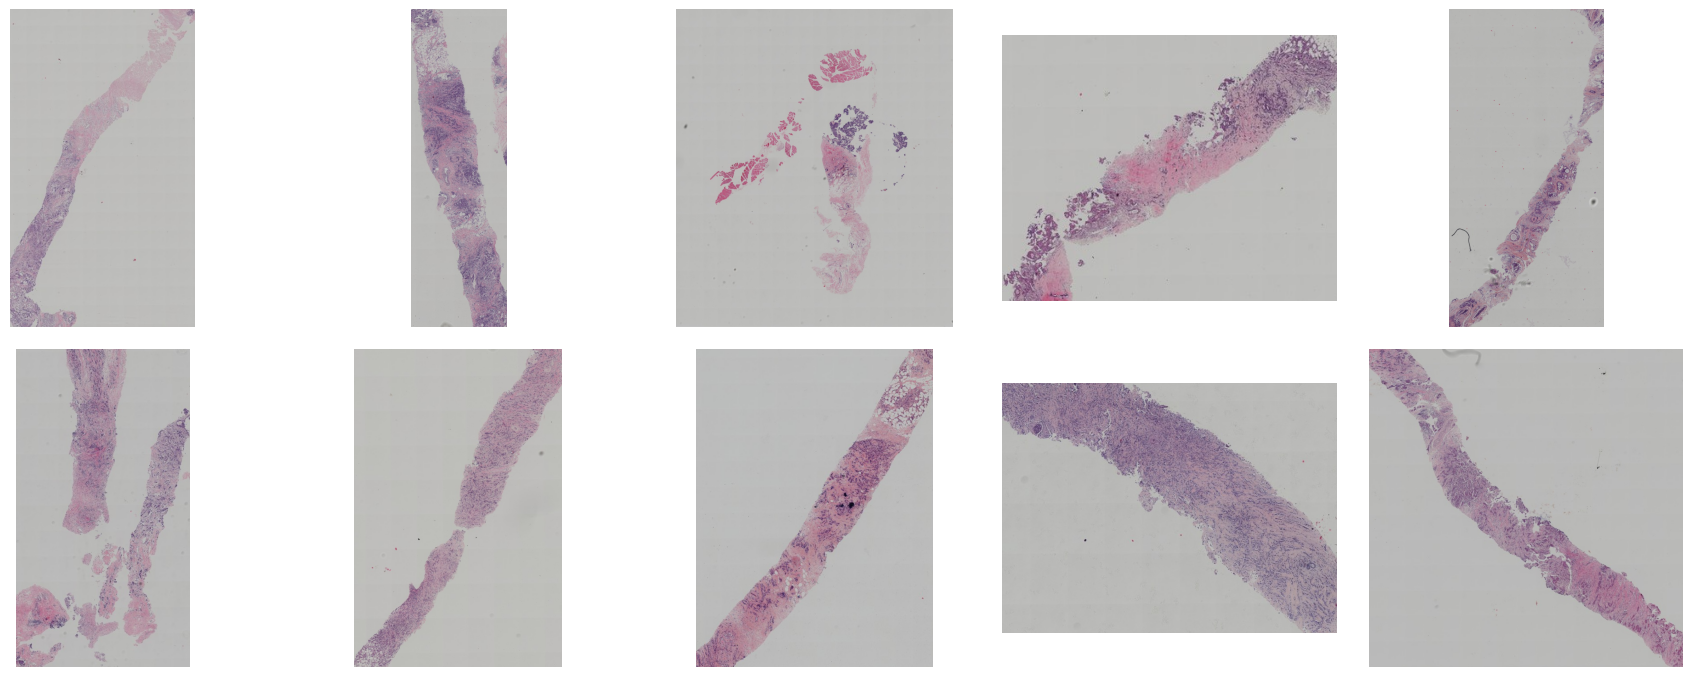

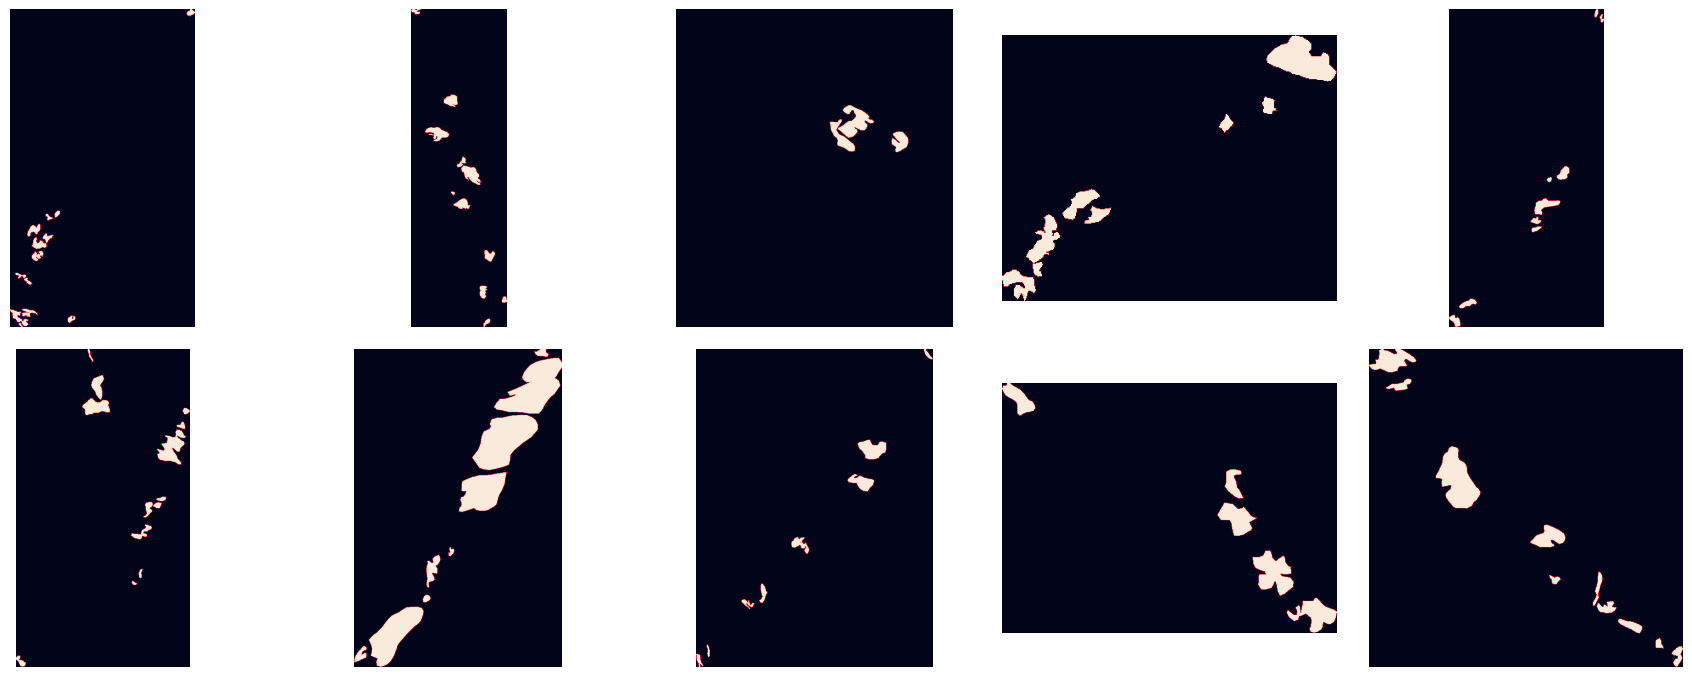

In [46]:
plot_10_images(data)
plot_10_images(masks)

In [47]:
patches = extract_patches_maskaware(data[1], masks[1], patch=256, n_patches=4)

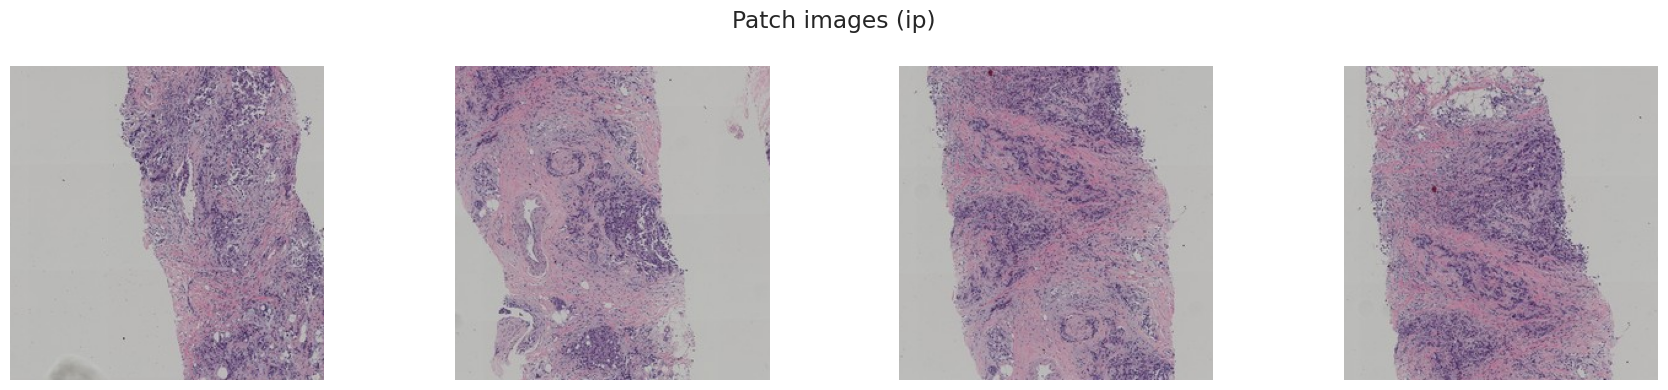

In [48]:
indices = list(range(4))

plt.figure(figsize=(18, 4))
for i, idx in enumerate(indices):
    ip, mp = patches[idx]         
    plt.subplot(1, len(indices), i+1)
    plt.imshow(ip)                 
    plt.axis("off")

plt.suptitle("Patch images (ip)")
plt.tight_layout()
plt.show()

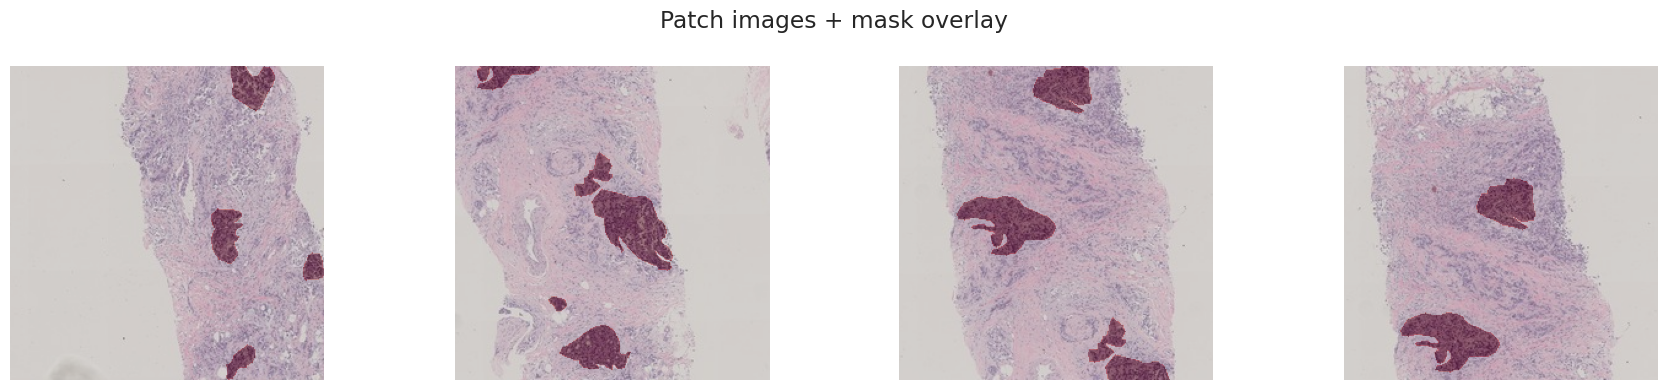

In [49]:
indices = list(range(4))

plt.figure(figsize=(18, 4))
for i, idx in enumerate(indices):
    ip, mp = patches[idx]
    plt.subplot(1, len(indices), i+1)
    plt.imshow(ip)
    plt.imshow(mp, cmap="Reds", alpha=0.35)
    plt.axis("off")

plt.suptitle("Patch images + mask overlay")
plt.tight_layout()
plt.show()

In [50]:
labels = pd.read_csv("/kaggle/input/tissues-noshrek/an2dl2526c2v2/train_labels.csv")

labels_map = {
    "Triple negative": 0,
    "Luminal A": 1,
    "Luminal B": 2,
    "HER2(+)": 3
}

# Tieni solo le label delle immagini effettivamente caricate
labels = labels[labels["sample_index"].isin(file_names)].copy()

# RIORDINA le label nello STESSO ordine delle immagini
labels = labels.set_index("sample_index").loc[file_names].reset_index()

# Mappa stringa -> intero (shape: [N], dtype int)
y_train_val = labels["label"].map(labels_map).to_numpy()

In [51]:
# converti liste in array di indici per train_test_split
idx = np.arange(len(data))

idx_train, idx_val = train_test_split(
    idx, random_state=SEED, test_size=0.1, stratify=y_train_val
)

X_train = [data[i] for i in idx_train]
M_train = [masks[i] for i in idx_train]
y_train = y_train_val[idx_train]

X_val = [data[i] for i in idx_val]
M_val = [masks[i] for i in idx_val]
y_val = y_train_val[idx_val]

In [52]:
# Define the number of classes
num_classes = len(np.unique(y_train))

print("Number of Classes:", num_classes)

Number of Classes: 4


In [53]:
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))

{0: 62, 1: 142, 2: 183, 3: 135}


In [54]:
class_counts = torch.tensor(counts, dtype=torch.float32, device=device)
weights = 1.0 / class_counts
weights = weights / weights.sum()  # normalize

In [55]:
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

val_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

In [56]:
class MILDataset(Dataset):
    def __init__(self, images, masks, labels=None, patch=256, n_patches=8,
                 transform_img=None, mode="train", seed=42):
        self.images = images
        self.masks = masks
        self.labels = labels
        self.patch = patch
        self.n_patches = n_patches
        self.transform_img = transform_img
        self.mode = mode
        self.seed = seed

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img  = self.images[idx]
        mask = self.masks[idx]

        # RNG: train random, val deterministic
        rng = np.random.default_rng(None if self.mode == "train" else (self.seed + idx))

        patches = extract_patches_maskaware(
            img, mask,
            patch=self.patch,
            n_patches=self.n_patches,
            rng=rng,                 
            min_mask_frac=0.01,      
            max_tries=50             
        )

        if len(patches) == 0:
            patches = [(img, mask)]  # fallback estremo

        if len(patches) < self.n_patches:
            idxs = rng.choice(len(patches), size=self.n_patches, replace=True)
            patches = [patches[i] for i in idxs]

        xb = []
        for ip, mp in patches:
            # NON fare ip[mp==0]=0
            if self.transform_img:
                ip = self.transform_img(ip)  # -> Tensor [3,H,W]
            else:
                ip = torch.from_numpy(ip).permute(2,0,1).float() / 255.0
            xb.append(ip)

        xb = torch.stack(xb, dim=0)  # [K,3,H,W]

        if self.labels is None:
            return xb
        y = int(self.labels[idx])
        return xb, y

In [57]:
batch_size = 4

In [58]:
train_dataset = MILDataset(X_train, M_train, y_train, patch=256, n_patches=8,
                           transform_img=train_transforms, mode="train", seed=SEED)
val_dataset   = MILDataset(X_val,   M_val,   y_val,   patch=256, n_patches=8,
                           transform_img=val_transforms, mode="val", seed=SEED)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

In [59]:
def freeze_batchnorm(model):
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.eval()
            for p in m.parameters():
                p.requires_grad = False

In [60]:
del X_train, M_train, X_val, M_val, y_train, y_val, data, masks, file_names
gc.collect()

93631

In [61]:
model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1) # WideResNet50-2, puoi cambiare variante
model.fc = nn.Linear(model.fc.in_features, num_classes)  # adattiamo l'output

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

In [62]:
for p in model.parameters():
    p.requires_grad = False
for p in model.fc.parameters():
    p.requires_grad = True

In [63]:
criterion = nn.CrossEntropyLoss(weight=weights)  # weights già su device
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)
scaler = torch.cuda.amp.GradScaler() if device.type == "cuda" else None

In [64]:
if not os.path.exists("models"):
    os.makedirs("models")

In [65]:
def mil_pool(logits_bkc: torch.Tensor, method="mean"):
    """
    logits_bkc: [B, K, C]
    returns:    [B, C]
    """
    if method == "mean":
        return logits_bkc.mean(dim=1)
    if method == "max":
        return logits_bkc.max(dim=1).values
    raise ValueError(f"Unknown pooling method: {method}")

In [85]:
def train_one_epoch_mil(model, loader, criterion, optimizer, scaler, device,
                        pool_method="mean", f1_average="macro"):
    model.train()
    running_loss = 0.0
    preds, targs = [], []

    for xb, y in loader:
        xb = xb.to(device, non_blocking=True)
        y  = y.to(device, non_blocking=True)

        B, K, Cc, H, W = xb.shape
        x = xb.view(B*K, Cc, H, W)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = model(x)                          # [B*K, C]
            logits = logits.view(B, K, -1)             # [B,K,C]
            logits_img = mil_pool(logits, method=pool_method)  # [B,C]
            loss = criterion(logits_img, y)

        if scaler is not None and device.type == "cuda":
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * B

        preds.append(logits_img.argmax(dim=1).detach().cpu().numpy())
        targs.append(y.detach().cpu().numpy())

    y_true = np.concatenate(targs)
    y_pred = np.concatenate(preds)

    epoch_loss = running_loss / len(loader.dataset)
    epoch_f1 = f1_score(y_true, y_pred, average=f1_average, zero_division=0)

    return epoch_loss, epoch_f1


@torch.no_grad()
def validate_one_epoch_mil(model, loader, criterion, device,
                           pool_method="mean", f1_average="macro"):
    model.eval()
    running_loss = 0.0
    preds, targs = [], []

    for xb, y in loader:
        xb = xb.to(device, non_blocking=True)
        y  = y.to(device, non_blocking=True)

        B, K, Cc, H, W = xb.shape
        x = xb.view(B*K, Cc, H, W)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = model(x)
            logits = logits.view(B, K, -1)
            logits_img = mil_pool(logits, method=pool_method)
            loss = criterion(logits_img, y)

        running_loss += loss.item() * B

        preds.append(logits_img.argmax(dim=1).cpu().numpy())
        targs.append(y.cpu().numpy())

    y_true = np.concatenate(targs)
    y_pred = np.concatenate(preds)

    epoch_loss = running_loss / len(loader.dataset)
    epoch_f1 = f1_score(y_true, y_pred, average=f1_average, zero_division=0)

    return epoch_loss, epoch_f1


def fit_mil(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
            patience=10, mode="max", pool_method="mean", f1_average="macro",
            experiment_name="mil", save_dir="models"):

    os.makedirs(save_dir, exist_ok=True)
    best_path = os.path.join(save_dir, f"{experiment_name}_model.pt")

    hist = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}

    best_metric = -1e9 if mode == "max" else 1e9
    patience_counter = 0
    best_epoch = 0

    for epoch in range(1, epochs + 1):
        tr_loss, tr_f1 = train_one_epoch_mil(
            model, train_loader, criterion, optimizer, scaler, device,
            pool_method=pool_method, f1_average=f1_average
        )
        va_loss, va_f1 = validate_one_epoch_mil(
            model, val_loader, criterion, device,
            pool_method=pool_method, f1_average=f1_average
        )

        hist["train_loss"].append(tr_loss)
        hist["val_loss"].append(va_loss)
        hist["train_f1"].append(tr_f1)
        hist["val_f1"].append(va_f1)

        print(f"Epoch {epoch:3d}/{epochs} | Train: {tr_loss:.4f} F1={tr_f1:.4f} | Val: {va_loss:.4f} F1={va_f1:.4f}")

        metric = va_f1
        improved = (metric > best_metric) if mode == "max" else (metric < best_metric)

        if improved:
            best_metric = metric
            best_epoch = epoch
            torch.save(model.state_dict(), best_path)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience > 0 and patience_counter >= patience:
                print(f"Early stopping @ epoch {epoch}")
                break

    model.load_state_dict(torch.load(best_path, map_location=device))
    print(f"Restored best epoch {best_epoch} | best val_f1={best_metric:.4f}")

    return model, hist

In [67]:
%%time
mil_model, mil_hist = fit_mil(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=100,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    patience=15,
    pool_method="mean",
    f1_average="weighted",         
    experiment_name="mil_resnet18"
)

best_val_f1 = max(mil_hist["val_f1"])
print(f"Best validation F1 ({'macro'}): {best_val_f1:.4f}")

Epoch   1/100 | Train: 1.3969 F1=0.3009 | Val: 1.4042 F1=0.1791
Epoch   2/100 | Train: 1.4013 F1=0.2810 | Val: 1.4010 F1=0.1905
Epoch   3/100 | Train: 1.3828 F1=0.2750 | Val: 1.4220 F1=0.1850
Epoch   4/100 | Train: 1.3713 F1=0.2980 | Val: 1.4143 F1=0.1902
Epoch   5/100 | Train: 1.3678 F1=0.3109 | Val: 1.3856 F1=0.2622
Epoch   6/100 | Train: 1.3845 F1=0.3093 | Val: 1.4062 F1=0.1929
Epoch   7/100 | Train: 1.3620 F1=0.3394 | Val: 1.3766 F1=0.3177
Epoch   8/100 | Train: 1.3687 F1=0.3200 | Val: 1.4062 F1=0.2134
Epoch   9/100 | Train: 1.3654 F1=0.3163 | Val: 1.3836 F1=0.2894
Epoch  10/100 | Train: 1.3471 F1=0.3467 | Val: 1.3807 F1=0.2314
Epoch  11/100 | Train: 1.3456 F1=0.3390 | Val: 1.3914 F1=0.2985
Epoch  12/100 | Train: 1.3454 F1=0.3492 | Val: 1.4096 F1=0.1417
Epoch  13/100 | Train: 1.3404 F1=0.3436 | Val: 1.4031 F1=0.2206
Epoch  14/100 | Train: 1.3365 F1=0.3616 | Val: 1.4119 F1=0.2112
Epoch  15/100 | Train: 1.3374 F1=0.3490 | Val: 1.3891 F1=0.3413
Epoch  16/100 | Train: 1.3322 F1=0.3623 

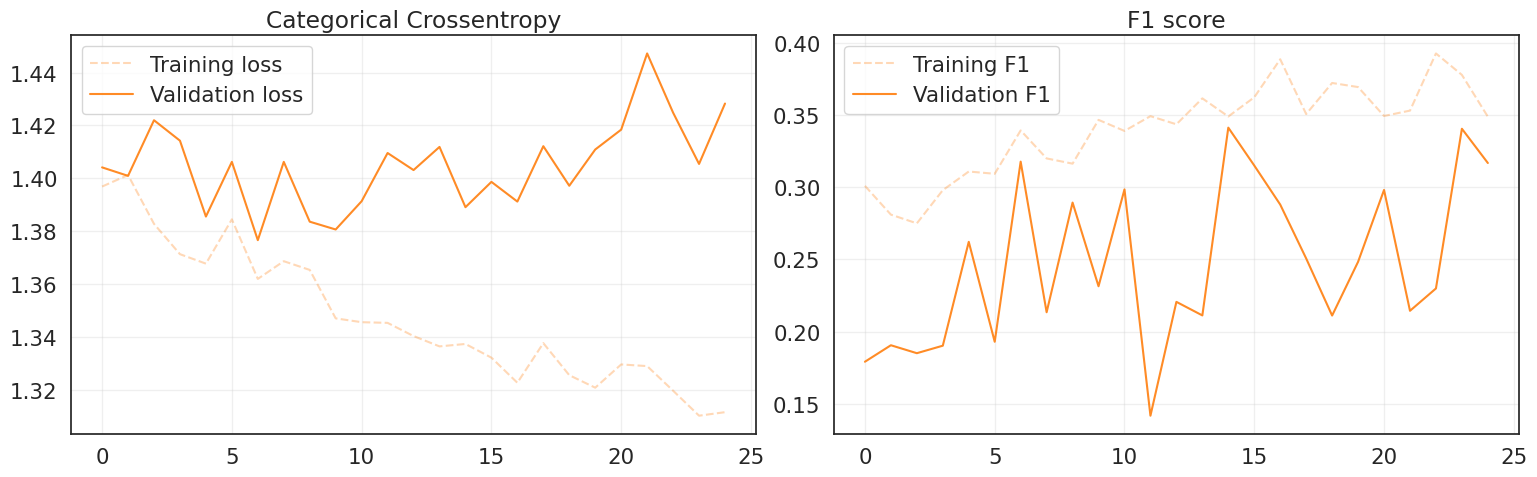

In [69]:
# @title Plot History
# Create a figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(mil_hist['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(mil_hist['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Categorical Crossentropy')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation Accuracy on the second axis
ax2.plot(mil_hist['train_f1'], label='Training F1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(mil_hist['val_f1'], label='Validation F1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

In [84]:
# --- freeze/unfreeze ---
for p in mil_model.parameters():
    p.requires_grad = True
#for p in mil_model.fc.parameters():
#    p.requires_grad = True
#for p in mil_model.layer4.parameters():
#    p.requires_grad = True
#for p in mil_model.layer3.parameters():
#    p.requires_grad = True
#for p in mil_model.layer2.parameters():
#   p.requires_grad = True

In [83]:
params = [p for p in mil_model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(params, lr=1e-4, weight_decay=1e-4)

In [70]:
UNFREEZE_SCHEDULE = {0:["fc"], 5:["layer4"], 10:["layer3"], 20:["layer2"]}

def fit_mil(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
            patience=8, mode="max", pool_method="mean", experiment_name="mil",
            f1_average="weighted"):

    os.makedirs("models", exist_ok=True)
    hist = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}

    best_metric = -1e9 if mode == "max" else 1e9
    patience_counter = 0
    best_epoch = 0
    best_path = f"models/{experiment_name}_model.pt"

    for epoch in range(epochs):

        # --- freeze/unfreeze ---
        for p in model.parameters():
            p.requires_grad = False

        # head
        for p in model.fc.parameters():
            p.requires_grad = True

        # progressive unfreeze
        if epoch >= 5:
            for p in model.layer4.parameters():
                p.requires_grad = True
        if epoch >= 10:
            for p in model.layer3.parameters():
                p.requires_grad = True
        if epoch >= 20:
            for p in model.layer2.parameters():
                p.requires_grad = True

        # freeze batchnorm (assumo tu l'abbia già definita)
        freeze_batchnorm(model)

        # re-build optimizer when schedule hits (ok farlo così)
        if epoch in UNFREEZE_SCHEDULE:
            params = [p for p in model.parameters() if p.requires_grad]
            optimizer = torch.optim.AdamW(params, lr=1e-4, weight_decay=1e-4)

        # --- TRAIN ---
        model.train()
        running_loss = 0.0
        preds, targs = [], []

        for xb, y in train_loader:
            xb = xb.to(device, non_blocking=True)   # [B,K,3,H,W]
            y  = y.to(device, non_blocking=True)

            B, K, Cc, H, W = xb.shape
            x = xb.view(B*K, Cc, H, W)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
                logits = model(x)                      # [B*K, C]
                logits = logits.view(B, K, -1)         # [B,K,C]
                logits_img = mil_pool(logits, method=pool_method)  # [B,C]
                loss = criterion(logits_img, y)

            if scaler is not None and device.type == "cuda":
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()

            running_loss += loss.item() * B
            preds.append(logits_img.argmax(dim=1).detach().cpu().numpy())
            targs.append(y.detach().cpu().numpy())

        tr_loss = running_loss / len(train_loader.dataset)
        tr_f1 = f1_score(np.concatenate(targs), np.concatenate(preds),
                         average=f1_average, zero_division=0)

        # --- VAL ---
        model.eval()
        running_loss = 0.0
        preds, targs = [], []

        with torch.no_grad():
            for xb, y in val_loader:
                xb = xb.to(device, non_blocking=True)
                y  = y.to(device, non_blocking=True)

                B, K, Cc, H, W = xb.shape
                x = xb.view(B*K, Cc, H, W)

                with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
                    logits = model(x)
                    logits = logits.view(B, K, -1)
                    logits_img = mil_pool(logits, method=pool_method)
                    loss = criterion(logits_img, y)

                running_loss += loss.item() * B
                preds.append(logits_img.argmax(dim=1).cpu().numpy())
                targs.append(y.cpu().numpy())

        va_loss = running_loss / len(val_loader.dataset)
        va_f1 = f1_score(np.concatenate(targs), np.concatenate(preds),
                         average=f1_average, zero_division=0)

        hist["train_loss"].append(tr_loss); hist["val_loss"].append(va_loss)
        hist["train_f1"].append(tr_f1);     hist["val_f1"].append(va_f1)

        print(f"Epoch {epoch+1:3d}/{epochs} | Train: {tr_loss:.4f} F1={tr_f1:.4f} | Val: {va_loss:.4f} F1={va_f1:.4f}")

        metric = va_f1
        improved = (metric > best_metric) if mode == "max" else (metric < best_metric)

        if improved:
            best_metric = metric
            best_epoch = epoch + 1
            torch.save(model.state_dict(), best_path)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience and patience_counter >= patience:
                print(f"Early stopping @ epoch {epoch+1}")
                break

    model.load_state_dict(torch.load(best_path, map_location=device))
    print(f"Restored best epoch {best_epoch} | best val_f1={best_metric:.4f}")
    return model, hist

In [86]:
%%time
# Fine-tune the model
ft_model, ft_history = fit_mil(
    model=mil_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=120,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    patience=15,
    pool_method="mean",
    experiment_name="mil_resnet18_ft"
)

final_val_acc = round(max(ft_history['val_f1']) * 100, 2)
print(f"Best validation F1 ({'weighted'}): {best_val_f1:.4f}")

Epoch   1/120 | Train: 1.2770 F1=0.4422 | Val: 1.7620 F1=0.2252
Epoch   2/120 | Train: 1.1553 F1=0.4900 | Val: 1.9070 F1=0.2536
Epoch   3/120 | Train: 1.1027 F1=0.5196 | Val: 2.0590 F1=0.2591
Epoch   4/120 | Train: 1.1102 F1=0.4890 | Val: 2.3953 F1=0.2326
Epoch   5/120 | Train: 1.0160 F1=0.5639 | Val: 1.9702 F1=0.3115
Epoch   6/120 | Train: 0.9174 F1=0.6047 | Val: 2.2350 F1=0.3347
Epoch   7/120 | Train: 0.8512 F1=0.6545 | Val: 2.2051 F1=0.3433
Epoch   8/120 | Train: 0.8084 F1=0.6655 | Val: 2.7810 F1=0.3062
Epoch   9/120 | Train: 0.8002 F1=0.6477 | Val: 3.0901 F1=0.1917
Epoch  10/120 | Train: 0.6515 F1=0.7416 | Val: 2.4719 F1=0.3286
Epoch  11/120 | Train: 0.6756 F1=0.7288 | Val: 2.3862 F1=0.3497
Epoch  12/120 | Train: 0.6116 F1=0.7748 | Val: 2.9430 F1=0.3310
Epoch  13/120 | Train: 0.5239 F1=0.8025 | Val: 2.9990 F1=0.2652
Epoch  14/120 | Train: 0.6076 F1=0.7723 | Val: 3.4604 F1=0.2850
Epoch  15/120 | Train: 0.4984 F1=0.8122 | Val: 3.1721 F1=0.1948
Epoch  16/120 | Train: 0.5437 F1=0.7837 

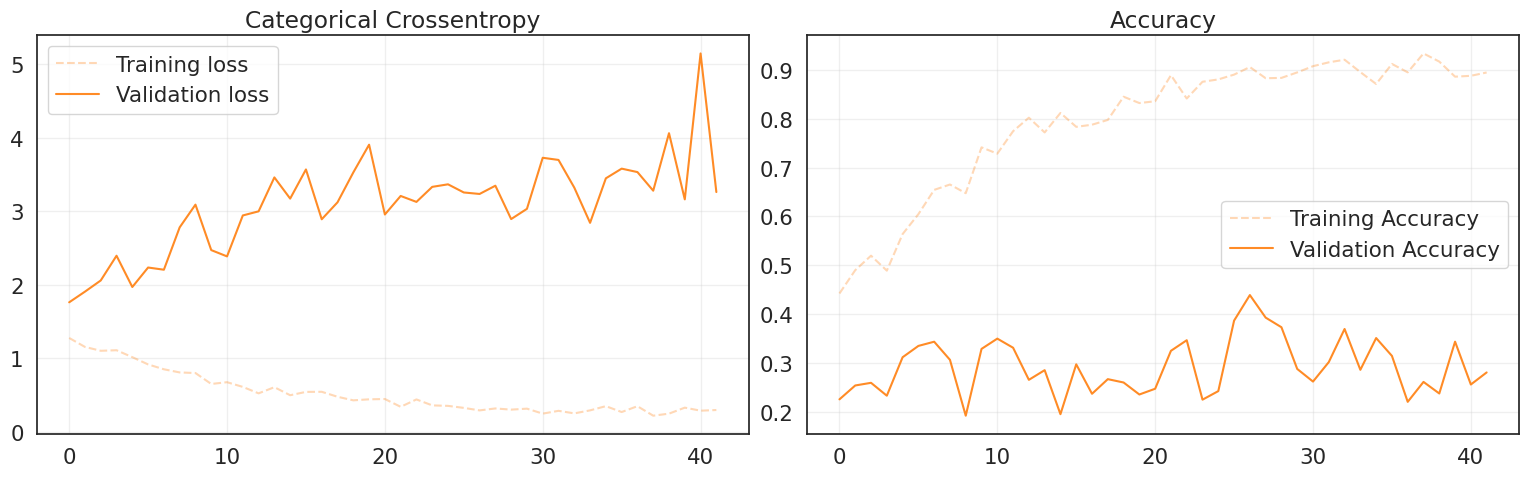

In [87]:
# @title Plot History
# Create a figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(ft_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(ft_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Categorical Crossentropy')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation Accuracy on the second axis
ax2.plot(ft_history['train_f1'], label='Training Accuracy', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(ft_history['val_f1'], label='Validation Accuracy', alpha=0.9, color='#ff7f0e')
ax2.set_title('Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

In [88]:
# Load the fine-tuned model for inference
best_model = ft_model

print("Model loaded successfully!")

Model loaded successfully!


In [89]:
test_data, test_masks, test_file_names = load_images_from_folder("/kaggle/input/tissues-noshrek/an2dl2526c2v2/test_data")
print(f"Loaded {len(test_data)} data")

Loaded 477 data


In [90]:
int_to_label = {
    0 : "Triple negative",
    1 : "Luminal A",
    2 : "Luminal B",
    3 : "HER2(+)"
}

def predict_one_image_mil(best_model, img, mask, patch=256, k=16, pool_method="mean"):
    best_model.eval()
    patches = extract_patches_maskaware(img, mask, patch=patch, n_patches=k)

    xb = []
    for ip, mp in patches:
        # DO NOT zero background unless you have evidence it helps.
        xb.append(val_transforms(ip))
    xb = torch.stack(xb).to(device)  # [K,3,H,W]

    with torch.no_grad(), torch.amp.autocast(device_type=device.type, enabled=(device.type=='cuda')):
        logits = model(xb)               # [K,C]
        logits = logits.unsqueeze(0)     # [1,K,C]
        pooled = mil_pool(logits, method=pool_method).squeeze(0)  # [C]
        pred = pooled.argmax().item()
    return pred

# build submission
patch_size = 256  # <-- define it, don’t freestyle variable names

sample_indices, predictions = [], []
for img, mask, fname in zip(test_data, test_masks, test_file_names):
    p = predict_one_image_mil(best_model, img, mask, patch=256, k=16, pool_method="mean")
    sample_indices.append(fname)
    predictions.append(int_to_label[int(p)])

submission_df = pd.DataFrame({
    'sample_index': sample_indices,
    'label': predictions
}).sort_values("sample_index").reset_index(drop=True)

os.makedirs("/kaggle/working/submissions", exist_ok=True)
submission_df.to_csv('/kaggle/working/submissions/mil_resnet18Patch6.csv', index=False)

In [91]:
submission_df.to_csv('/kaggle/working/submissions/mil_resnet18Patch7.csv', index=False)